# Evaluación Parcial 3 - Proyecto End-to-End ETL, Dashboard, API, Git y Docker

**Asignatura:** Programación para la Ciencia de Datos  
**Proyecto:** Análisis de actividad física por pasos horarios  


## 1. Importación de librerías y configuración general

Se cargan librerías estándar para ETL, validación, visualización, manejo de errores, logging y base de datos SQLite.

In [14]:
from pathlib import Path
import pandas as pd
import numpy as np
import sqlite3
import json
import shutil
import logging
from datetime import datetime
import matplotlib.pyplot as plt

# Configuración de logs para seguimiento profesional del pipeline
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s'
)
logger = logging.getLogger('pipeline_etl')

print('Librerías cargadas correctamente')

Librerías cargadas correctamente


## 2. Definición de rutas del proyecto



In [15]:
# Rutas base en Colab
BASE_DIR = Path('/content')
DATA_DIR = BASE_DIR / 'data'
DATA_RAW = DATA_DIR / 'raw'
DATA_OG = DATA_DIR / 'og'
DATA_PROCESSED = DATA_DIR / 'processed'
DATA_DATABASE = DATA_DIR / 'database'
REPORTS_DIR = BASE_DIR / 'reports'

# Crear carpetas si no existen
for carpeta in [DATA_RAW, DATA_OG, DATA_PROCESSED, DATA_DATABASE, REPORTS_DIR]:
    carpeta.mkdir(parents=True, exist_ok=True)

# Nombres oficiales actualizados según tu GitHub
RAW_FILE = 'hourlySteps_sucio.csv'
OG_FILE = 'hourlySteps_merged.csv'
PROCESSED_FILE = 'hourlySteps.csv'

RAW_PATH = DATA_RAW / RAW_FILE
OG_PATH = DATA_OG / OG_FILE
PROCESSED_PATH = DATA_PROCESSED / PROCESSED_FILE
DB_PATH = DATA_DATABASE / 'actividad_fisica.db'

print('Carpetas configuradas:')
print('RAW:', DATA_RAW)
print('OG:', DATA_OG)
print('PROCESSED:', DATA_PROCESSED)
print('DATABASE:', DATA_DATABASE)

Carpetas configuradas:
RAW: /content/data/raw
OG: /content/data/og
PROCESSED: /content/data/processed
DATABASE: /content/data/database


## 3. Carga y organización de archivos con `pd.read_csv()`



In [16]:
archivos_esperados = {
    'raw': {
        'nombre_oficial': RAW_FILE,
        'alternativos': [RAW_FILE],
        'destino': RAW_PATH
    },
    'og': {
        'nombre_oficial': OG_FILE,
        'alternativos': [OG_FILE],
        'destino': OG_PATH
    },
    'processed': {
        'nombre_oficial': PROCESSED_FILE,
        'alternativos': [PROCESSED_FILE, 'hourlySteps_clean(1).csv'],
        'destino': PROCESSED_PATH
    }
}

rutas_busqueda = [
    BASE_DIR,
    DATA_RAW,
    DATA_OG,
    DATA_PROCESSED,
    Path.cwd()
]

def buscar_archivo(nombres_posibles):
    for carpeta in rutas_busqueda:
        for nombre in nombres_posibles:
            ruta = carpeta / nombre
            if ruta.exists():
                return ruta
    raise FileNotFoundError(
        f'No se encontró ninguno de estos archivos: {nombres_posibles}. '
        'Verifica que estén subidos a /content/ o dentro de /content/data/...'
    )

rutas_archivos = {}

for clave, info in archivos_esperados.items():
    ruta_encontrada = buscar_archivo(info['alternativos'])

    # Verificación real de lectura con pd.read_csv
    df_temporal = pd.read_csv(ruta_encontrada)

    print(
        f"{clave.upper()} -> {ruta_encontrada.name}: cargado correctamente desde {ruta_encontrada} "
        f"| filas={df_temporal.shape[0]} | columnas={df_temporal.shape[1]}"
    )

    destino = info['destino']
    if ruta_encontrada.resolve() != destino.resolve():
        shutil.copy(ruta_encontrada, destino)

    rutas_archivos[clave] = destino

print('Archivos organizados correctamente en:')
print('RAW:', rutas_archivos['raw'])
print('OG:', rutas_archivos['og'])
print('PROCESSED:', rutas_archivos['processed'])

RAW -> hourlySteps_sucio.csv: cargado correctamente desde /content/hourlySteps_sucio.csv | filas=28901 | columnas=3
OG -> hourlySteps_merged.csv: cargado correctamente desde /content/hourlySteps_merged.csv | filas=24084 | columnas=3
PROCESSED -> hourlySteps.csv: cargado correctamente desde /content/hourlySteps.csv | filas=21267 | columnas=7
Archivos organizados correctamente en:
RAW: /content/data/raw/hourlySteps_sucio.csv
OG: /content/data/og/hourlySteps_merged.csv
PROCESSED: /content/data/processed/hourlySteps.csv


## 4. Lectura oficial de las tres fuentes CSV

Desde este punto se trabaja con las rutas oficiales del proyecto.

In [17]:
df_sucio = pd.read_csv(RAW_PATH)
df_merged = pd.read_csv(OG_PATH)
df_clean = pd.read_csv(PROCESSED_PATH)

print('Dataset sucio:', df_sucio.shape)
print('Dataset original merged:', df_merged.shape)
print('Dataset procesado:', df_clean.shape)

display(df_sucio.head())
display(df_merged.head())
display(df_clean.head())

Dataset sucio: (28901, 3)
Dataset original merged: (24084, 3)
Dataset procesado: (21267, 7)


,Id,ActivityHour,StepTotal
0,1.503960e+09,3/12/2016 12:00:00 AM,0.0
1,1.503960e+09,3/12/2016 1:00:00 AM,NaN
2,1.503960e+09,3/12/2016 2:00:00 AM,0.0
3,1.503960e+09,3/12/2016 3:00:00 AM,0.0
4,1.503960e+09,3/12/2016 4:00:00 AM,0.0


,Id,ActivityHour,StepTotal
0,1503960366,3/12/2016 12:00:00 AM,0
1,1503960366,3/12/2016 1:00:00 AM,0
2,1503960366,3/12/2016 2:00:00 AM,0
3,1503960366,3/12/2016 3:00:00 AM,0
4,1503960366,3/12/2016 4:00:00 AM,0


,Id,ActivityHour,StepTotal,Hora,Dia,FinDeSemana,StepTotal_scaled
0,1.503960e+09,2016-03-12 00:00:00,0.0,0,Saturday,1,-0.432248
1,1.503960e+09,2016-03-12 01:00:00,0.0,1,Saturday,1,-0.432248
2,1.503960e+09,2016-03-12 02:00:00,0.0,2,Saturday,1,-0.432248
3,1.503960e+09,2016-03-12 03:00:00,0.0,3,Saturday,1,-0.432248
4,1.503960e+09,2016-03-12 04:00:00,0.0,4,Saturday,1,-0.432248


## 5. Validación de esquemas

Se valida que los datasets tengan las columnas mínimas requeridas para continuar el pipeline.

In [18]:
COLUMNAS_BASE = ['Id', 'ActivityHour', 'StepTotal']
COLUMNAS_PROCESADAS = ['Id', 'ActivityHour', 'StepTotal', 'Hora', 'Dia', 'FinDeSemana']

def validar_columnas(df, columnas_requeridas, nombre_df):
    faltantes = [col for col in columnas_requeridas if col not in df.columns]
    if faltantes:
        raise ValueError(f'{nombre_df} no cumple el esquema. Faltan columnas: {faltantes}')
    logger.info(f'{nombre_df}: esquema validado correctamente')
    return True

validar_columnas(df_sucio, COLUMNAS_BASE, 'df_sucio')
validar_columnas(df_merged, COLUMNAS_BASE, 'df_merged')
validar_columnas(df_clean, COLUMNAS_BASE, 'df_clean')

if all(col in df_clean.columns for col in COLUMNAS_PROCESADAS):
    print('El dataset procesado ya contiene variables transformadas:', COLUMNAS_PROCESADAS)
else:
    print('El dataset procesado no contiene todas las variables transformadas; serán generadas más adelante si corresponde.')

El dataset procesado ya contiene variables transformadas: ['Id', 'ActivityHour', 'StepTotal', 'Hora', 'Dia', 'FinDeSemana']


## 6. Diagnóstico de calidad de datos

Se revisan nulos, duplicados, tipos de datos y estadísticas generales.

In [19]:
def diagnostico_calidad(df, nombre):
    resumen = pd.DataFrame({
        'columna': df.columns,
        'tipo_dato': [str(df[col].dtype) for col in df.columns],
        'nulos': [df[col].isna().sum() for col in df.columns],
        'nulos_%': [round(df[col].isna().mean() * 100, 2) for col in df.columns],
        'unicos': [df[col].nunique(dropna=True) for col in df.columns]
    })

    print(f'\n===== Diagnóstico: {nombre} =====')
    print('Filas:', df.shape[0])
    print('Columnas:', df.shape[1])
    print('Duplicados:', df.duplicated().sum())
    display(resumen)
    return resumen

resumen_sucio = diagnostico_calidad(df_sucio, 'Dataset sucio')
resumen_merged = diagnostico_calidad(df_merged, 'Dataset original merged')
resumen_clean = diagnostico_calidad(df_clean, 'Dataset procesado')


===== Diagnóstico: Dataset sucio =====
Filas: 28901
Columnas: 3
Duplicados: 4444


,columna,tipo_dato,nulos,nulos_%,unicos
0,Id,float64,1445,5.0,34
1,ActivityHour,object,1445,5.0,755
2,StepTotal,float64,1445,5.0,2179



===== Diagnóstico: Dataset original merged =====
Filas: 24084
Columnas: 3
Duplicados: 0


,columna,tipo_dato,nulos,nulos_%,unicos
0,Id,int64,0,0.0,34
1,ActivityHour,object,0,0.0,755
2,StepTotal,int64,0,0.0,2216



===== Diagnóstico: Dataset procesado =====
Filas: 21267
Columnas: 7
Duplicados: 0


,columna,tipo_dato,nulos,nulos_%,unicos
0,Id,float64,0,0.0,34
1,ActivityHour,object,0,0.0,755
2,StepTotal,float64,0,0.0,2108
3,Hora,int64,0,0.0,24
4,Dia,object,0,0.0,7
5,FinDeSemana,int64,0,0.0,2
6,StepTotal_scaled,float64,0,0.0,2108


## 7. Transformación ETL desde el dataset sucio

Esta sección limpia el dataset sucio y genera una versión procesada.  
Se aplica:

- Corrección de tipos de datos.
- Conversión de fecha/hora.
- Eliminación de registros inválidos.
- Tratamiento de valores nulos.
- Eliminación de duplicados.
- Creación de variables `Hora`, `Dia` y `FinDeSemana`.
- Escalamiento simple de `StepTotal`.

In [20]:
def transformar_hourly_steps(df):
    df_etl = df.copy()

    # Validación inicial
    validar_columnas(df_etl, COLUMNAS_BASE, 'df_etl')

    # Conversión de tipos
    df_etl['Id'] = pd.to_numeric(df_etl['Id'], errors='coerce')
    df_etl['StepTotal'] = pd.to_numeric(df_etl['StepTotal'], errors='coerce')
    df_etl['ActivityHour'] = pd.to_datetime(df_etl['ActivityHour'], errors='coerce')

    # Eliminar registros críticos inválidos
    df_etl = df_etl.dropna(subset=['Id', 'ActivityHour'])

    # Imputar StepTotal con mediana si hay nulos
    if df_etl['StepTotal'].isna().sum() > 0:
        mediana = df_etl['StepTotal'].median()
        df_etl['StepTotal'] = df_etl['StepTotal'].fillna(mediana)

    # Evitar pasos negativos en caso de datos erróneos
    df_etl = df_etl[df_etl['StepTotal'] >= 0]

    # Eliminar duplicados
    df_etl = df_etl.drop_duplicates()

    # Variables derivadas
    df_etl['Hora'] = df_etl['ActivityHour'].dt.hour
    df_etl['Dia'] = df_etl['ActivityHour'].dt.day_name()
    df_etl['FinDeSemana'] = df_etl['ActivityHour'].dt.dayofweek.isin([5, 6]).astype(int)

    # Escalamiento manual tipo z-score
    media = df_etl['StepTotal'].mean()
    std = df_etl['StepTotal'].std()
    if std == 0 or pd.isna(std):
        df_etl['StepTotal_scaled'] = 0
    else:
        df_etl['StepTotal_scaled'] = (df_etl['StepTotal'] - media) / std

    # Orden final
    columnas_finales = ['Id', 'ActivityHour', 'StepTotal', 'Hora', 'Dia', 'FinDeSemana', 'StepTotal_scaled']
    df_etl = df_etl[columnas_finales].sort_values(['Id', 'ActivityHour']).reset_index(drop=True)

    return df_etl

df_etl = transformar_hourly_steps(df_sucio)

print('Dataset ETL generado:', df_etl.shape)
display(df_etl.head())
display(df_etl.tail())

/tmp/ipykernel_15434/1859224732.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_etl['ActivityHour'] = pd.to_datetime(df_etl['ActivityHour'], errors='coerce')


Dataset ETL generado: (22541, 7)


,Id,ActivityHour,StepTotal,Hora,Dia,FinDeSemana,StepTotal_scaled
0,1.503960e+09,2016-03-12 00:00:00,0.0,0,Saturday,1,-0.417639
1,1.503960e+09,2016-03-12 01:00:00,10.0,1,Saturday,1,-0.402224
2,1.503960e+09,2016-03-12 02:00:00,0.0,2,Saturday,1,-0.417639
3,1.503960e+09,2016-03-12 03:00:00,0.0,3,Saturday,1,-0.417639
4,1.503960e+09,2016-03-12 04:00:00,0.0,4,Saturday,1,-0.417639


,Id,ActivityHour,StepTotal,Hora,Dia,FinDeSemana,StepTotal_scaled
22536,8.877689e+09,2016-04-12 02:00:00,0.0,2,Tuesday,0,-0.417639
22537,8.877689e+09,2016-04-12 03:00:00,0.0,3,Tuesday,0,-0.417639
22538,8.877689e+09,2016-04-12 05:00:00,0.0,5,Tuesday,0,-0.417639
22539,8.877689e+09,2016-04-12 07:00:00,964.0,7,Tuesday,0,1.068358
22540,8.877689e+09,2016-04-12 08:00:00,834.0,8,Tuesday,0,0.867964


## 8. Comparación entre dataset procesado existente y dataset generado por ETL

Se compara el archivo limpio existente (`data/processed/hourlySteps.csv`) con el resultado generado desde el dataset sucio.

In [21]:
comparacion = pd.DataFrame({
    'fuente': ['processed_actual', 'etl_generado'],
    'filas': [df_clean.shape[0], df_etl.shape[0]],
    'columnas': [df_clean.shape[1], df_etl.shape[1]],
    'nulos_totales': [df_clean.isna().sum().sum(), df_etl.isna().sum().sum()],
    'duplicados': [df_clean.duplicated().sum(), df_etl.duplicated().sum()],
    'promedio_pasos': [round(df_clean['StepTotal'].mean(), 2), round(df_etl['StepTotal'].mean(), 2)]
})

display(comparacion)

,fuente,filas,columnas,nulos_totales,duplicados,promedio_pasos
0,processed_actual,21267,7,0,0,286.10
1,etl_generado,22541,7,0,0,270.93


## 9. Guardado de datos procesados

Se guarda el resultado generado por el ETL en `data/processed/hourlySteps_etl_generado.csv`.  
No se sobrescribe automáticamente `hourlySteps.csv` para evitar perder el archivo limpio actual del repositorio.

In [22]:
ETL_OUTPUT_PATH = DATA_PROCESSED / 'hourlySteps_etl_generado.csv'
df_etl.to_csv(ETL_OUTPUT_PATH, index=False)

print(f'Dataset ETL exportado en: {ETL_OUTPUT_PATH}')

Dataset ETL exportado en: /content/data/processed/hourlySteps_etl_generado.csv


## 10. Integración con fuente SQL usando SQLite

Para cubrir una fuente SQL, se guarda el dataset procesado en una base SQLite y luego se consulta con SQL.

In [23]:
conn = sqlite3.connect(DB_PATH)

df_etl.to_sql('hourly_steps', conn, if_exists='replace', index=False)

query_kpis = '''
SELECT
    COUNT(*) AS total_registros,
    ROUND(AVG(StepTotal), 2) AS promedio_pasos,
    MAX(StepTotal) AS maximo_pasos,
    MIN(StepTotal) AS minimo_pasos
FROM hourly_steps;
'''

kpis_sql = pd.read_sql_query(query_kpis, conn)
display(kpis_sql)

conn.close()
print('Base SQLite creada correctamente en:', DB_PATH)

,total_registros,promedio_pasos,maximo_pasos,minimo_pasos
0,22541,270.93,10565.0,0.0


Base SQLite creada correctamente en: /content/data/database/actividad_fisica.db


## 11. Fuente tipo API REST simulada

En un proyecto completo, esta información podría venir desde una API REST real.  
Para mantener el notebook reproducible en Colab sin depender de internet, se simula una respuesta JSON tipo API con parámetros de negocio.

In [24]:
respuesta_api_simulada = {
    'proyecto': 'Actividad física por pasos horarios',
    'unidad_negocio': 'Bienestar y monitoreo de actividad',
    'umbral_bajo_movimiento': 500,
    'umbral_alto_movimiento': 3000,
    'fecha_consulta': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'fuente': 'API REST simulada para parámetros de negocio'
}

API_JSON_PATH = DATA_PROCESSED / 'api_parametros_negocio.json'
with open(API_JSON_PATH, 'w', encoding='utf-8') as f:
    json.dump(respuesta_api_simulada, f, ensure_ascii=False, indent=4)

with open(API_JSON_PATH, 'r', encoding='utf-8') as f:
    parametros_api = json.load(f)

parametros_api

{'proyecto': 'Actividad física por pasos horarios',
 'unidad_negocio': 'Bienestar y monitoreo de actividad',
 'umbral_bajo_movimiento': 500,
 'umbral_alto_movimiento': 3000,
 'fecha_consulta': '2026-06-19 21:41:35',
 'fuente': 'API REST simulada para parámetros de negocio'}

## 12. Clasificación de registros según parámetros de negocio

Se integran los parámetros de la fuente tipo API con el dataset procesado.

In [25]:
umbral_bajo = parametros_api['umbral_bajo_movimiento']
umbral_alto = parametros_api['umbral_alto_movimiento']

def clasificar_actividad(pasos):
    if pasos < umbral_bajo:
        return 'Baja actividad'
    elif pasos >= umbral_alto:
        return 'Alta actividad'
    return 'Actividad media'

df_dashboard = df_etl.copy()
df_dashboard['CategoriaActividad'] = df_dashboard['StepTotal'].apply(clasificar_actividad)

DASHBOARD_DATA_PATH = DATA_PROCESSED / 'hourlySteps_dashboard.csv'
df_dashboard.to_csv(DASHBOARD_DATA_PATH, index=False)

print('Dataset para dashboard exportado en:', DASHBOARD_DATA_PATH)
display(df_dashboard.head())

Dataset para dashboard exportado en: /content/data/processed/hourlySteps_dashboard.csv


,Id,ActivityHour,StepTotal,Hora,Dia,FinDeSemana,StepTotal_scaled,CategoriaActividad
0,1.503960e+09,2016-03-12 00:00:00,0.0,0,Saturday,1,-0.417639,Baja actividad
1,1.503960e+09,2016-03-12 01:00:00,10.0,1,Saturday,1,-0.402224,Baja actividad
2,1.503960e+09,2016-03-12 02:00:00,0.0,2,Saturday,1,-0.417639,Baja actividad
3,1.503960e+09,2016-03-12 03:00:00,0.0,3,Saturday,1,-0.417639,Baja actividad
4,1.503960e+09,2016-03-12 04:00:00,0.0,4,Saturday,1,-0.417639,Baja actividad


## 13. KPIs principales para dashboard ejecutivo

In [26]:
kpis = {
    'total_registros': int(len(df_dashboard)),
    'usuarios_unicos': int(df_dashboard['Id'].nunique()),
    'promedio_pasos': float(round(df_dashboard['StepTotal'].mean(), 2)),
    'maximo_pasos': float(df_dashboard['StepTotal'].max()),
    'porcentaje_baja_actividad': float(round((df_dashboard['CategoriaActividad'].eq('Baja actividad').mean()) * 100, 2))
}

kpis_path = DATA_PROCESSED / 'kpis_dashboard.json'
with open(kpis_path, 'w', encoding='utf-8') as f:
    json.dump(kpis, f, ensure_ascii=False, indent=4)

kpis

{'total_registros': 22541,
 'usuarios_unicos': 34,
 'promedio_pasos': 270.93,
 'maximo_pasos': 10565.0,
 'porcentaje_baja_actividad': 84.28}

## 14. Visualizaciones base

Estas visualizaciones sirven como respaldo para la presentación y para diseñar el dashboard interactivo.

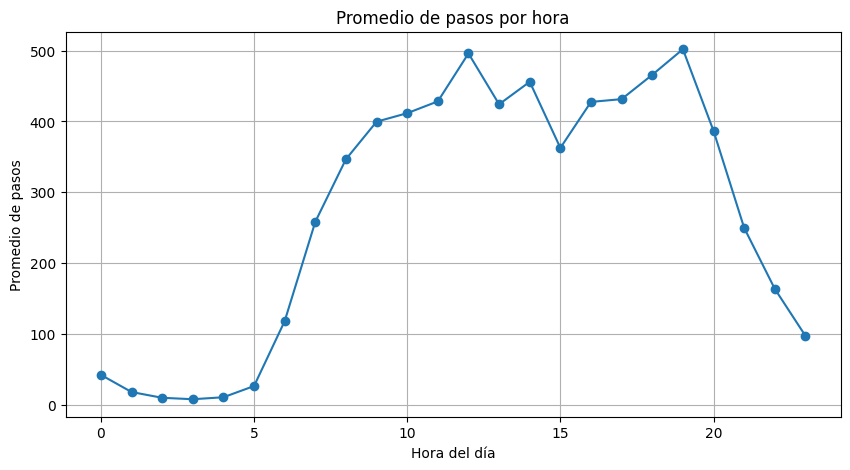

In [27]:
# Promedio de pasos por hora
pasos_hora = df_dashboard.groupby('Hora')['StepTotal'].mean().reset_index()

plt.figure(figsize=(10, 5))
plt.plot(pasos_hora['Hora'], pasos_hora['StepTotal'], marker='o')
plt.title('Promedio de pasos por hora')
plt.xlabel('Hora del día')
plt.ylabel('Promedio de pasos')
plt.grid(True)
plt.show()

,CategoriaActividad,Cantidad
0,Baja actividad,18997
1,Actividad media,3255
2,Alta actividad,289


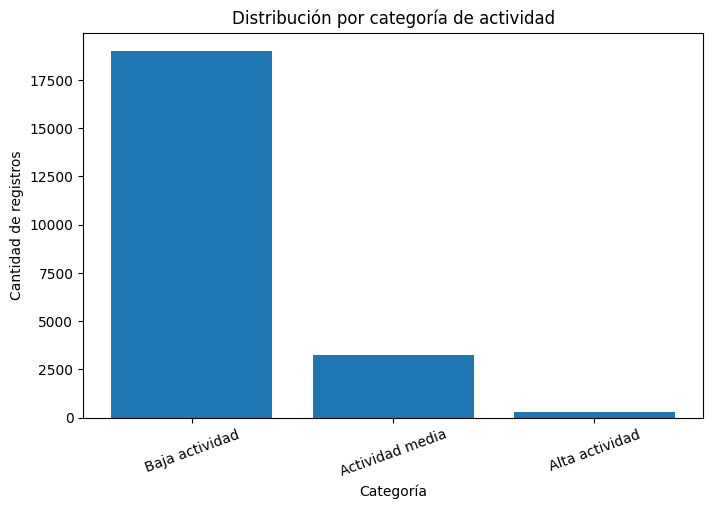

In [28]:
# Distribución por categoría de actividad
conteo_categoria = df_dashboard['CategoriaActividad'].value_counts().reset_index()
conteo_categoria.columns = ['CategoriaActividad', 'Cantidad']

display(conteo_categoria)

plt.figure(figsize=(8, 5))
plt.bar(conteo_categoria['CategoriaActividad'], conteo_categoria['Cantidad'])
plt.title('Distribución por categoría de actividad')
plt.xlabel('Categoría')
plt.ylabel('Cantidad de registros')
plt.xticks(rotation=20)
plt.show()

## 15. Validaciones finales del pipeline

Estas validaciones ayudan a demostrar control de calidad y manejo de errores.

In [29]:
validaciones_finales = {
    'sin_nulos_columnas_principales': bool(df_dashboard[['Id', 'ActivityHour', 'StepTotal']].isna().sum().sum() == 0),
    'sin_duplicados': bool(df_dashboard.duplicated().sum() == 0),
    'step_total_numerico': bool(pd.api.types.is_numeric_dtype(df_dashboard['StepTotal'])),
    'activityhour_datetime': bool(pd.api.types.is_datetime64_any_dtype(df_dashboard['ActivityHour'])),
    'columnas_dashboard': list(df_dashboard.columns),
    'fecha_validacion': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
}

validaciones_path = REPORTS_DIR / 'validaciones_finales.json'
with open(validaciones_path, 'w', encoding='utf-8') as f:
    json.dump(validaciones_finales, f, ensure_ascii=False, indent=4)

validaciones_finales

{'sin_nulos_columnas_principales': True,
 'sin_duplicados': True,
 'step_total_numerico': True,
 'activityhour_datetime': True,
 'columnas_dashboard': ['Id',
  'ActivityHour',
  'StepTotal',
  'Hora',
  'Dia',
  'FinDeSemana',
  'StepTotal_scaled',
  'CategoriaActividad'],
 'fecha_validacion': '2026-06-19 21:41:36'}

## 16. Resumen final para defensa

Este resumen puede usarse como base para explicar el notebook en la presentación.

In [30]:
print('RESUMEN FINAL DEL PIPELINE')
print('-' * 40)
print('Fuente RAW:', RAW_PATH)
print('Fuente OG:', OG_PATH)
print('Fuente PROCESSED:', PROCESSED_PATH)
print('Dataset ETL generado:', ETL_OUTPUT_PATH)
print('Dataset dashboard:', DASHBOARD_DATA_PATH)
print('Base SQLite:', DB_PATH)
print('KPIs JSON:', kpis_path)
print('Validaciones:', validaciones_path)
print('-' * 40)
print('Filas procesadas:', len(df_dashboard))
print('Usuarios únicos:', df_dashboard['Id'].nunique())
print('Promedio de pasos:', round(df_dashboard['StepTotal'].mean(), 2))
print('Nulos totales:', df_dashboard.isna().sum().sum())
print('Duplicados:', df_dashboard.duplicated().sum())

RESUMEN FINAL DEL PIPELINE
----------------------------------------
Fuente RAW: /content/data/raw/hourlySteps_sucio.csv
Fuente OG: /content/data/og/hourlySteps_merged.csv
Fuente PROCESSED: /content/data/processed/hourlySteps.csv
Dataset ETL generado: /content/data/processed/hourlySteps_etl_generado.csv
Dataset dashboard: /content/data/processed/hourlySteps_dashboard.csv
Base SQLite: /content/data/database/actividad_fisica.db
KPIs JSON: /content/data/processed/kpis_dashboard.json
Validaciones: /content/reports/validaciones_finales.json
----------------------------------------
Filas procesadas: 22541
Usuarios únicos: 34
Promedio de pasos: 270.93
Nulos totales: 0
Duplicados: 0


## 17. Próximos archivos que deben ir en GitHub

Después de este notebook, el repositorio debe incluir:

```text
dashboards/app_streamlit.py
api/api.py
docker/Dockerfile
docker/docker-compose.yml
tests/test_etl.py
docs/arquitectura.md
docs/guia_instalacion.md
docs/manual_usuario.md
docs/evidencia_git.md
requirements.txt
.env.example
```

Este notebook deja lista la base de datos y los archivos procesados para que el dashboard y la API puedan consumirlos.